# __`Social Data Analysis`__ 

__Generalities, Complex Networks and Node-Centric Metrics__

In this practical work, we will first check  :
 - if a network satisfies the 3 constraints to be considered as a complex network and 
 - then, we will determine how important nodes are within this network. 

The library we will use for handling networks is networkx

### __`Install the expecting libraries`__ 
(not necessary if you are certain these libs are installed on your system)

In [1]:
#%pip -q install --upgrade pip
#%pip -q install pandas
#%pip -q install networkx
#%pip -q install ipython-cypher
#%pip -q install py2neo
#%pip -q install neo4j
#%pip -q install matplotlib
#%pip -q install neo4j-viz
#%pip -q install graphdatascience
#%pip -q install palettable

### __`Import the useful packages`__     
You can avoid the first line if you are not using a Jupyter notebook. This line enables the visualization to be displayed in the notebook.

In [2]:
%matplotlib inline
import networkx as nx 
import pandas as pd
import numpy as np
import random
from networkx.algorithms.community import * 
import matplotlib.pyplot as plt
import os
import json

In [3]:
# Obviously, you must replace the path below by the appropriate path
workspace = "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_FLLGRF/" 
path = "TP3/Clean_Database/database/Everything/"
file1 = "database_formated_for_NetworkX.graphml"
pathData = workspace + path + file1

In [4]:
G = nx.read_graphml(pathData, node_type=str, edge_key_type=str)

## __`Check the network properties`__

### `Plot the degree distribution of the graph`
  1. Calculate and store the degree of each node     
    - The number of node'neighbours represents its degree $d_{v}= |N(v)|$       
    - in-degree dv in and out-degree dvout :
      - incoming neighbours $N_{in}(v) d_v^{in}$ : number of edges pointing to node v
      - outcoming neighbours $N_{out}(v) d_v^{out}$ : number of edges pointing away from node v    
2. Convert the result (a dict) into a Pandas object, a Series          

In [5]:
import pandas as pd

def make_dataframe(GD):
#df1 = pd.DataFrame(GD, columns=['ID', 'Node name']) 
    df2 = pd.DataFrame(GD.degree(), columns=['ID', 'degree neighb']) 
  #  df2 = pd.DataFrame(GD.number_of_nodes(), columns=['ID', 'number nodes']) 
    df3 = pd.DataFrame(GD.in_degree() , columns=['ID', 'degree in']) 
    df4 = pd.DataFrame(GD.out_degree() , columns=['ID', 'degree out']) 
    df5 = pd.DataFrame(GD.in_degree(weight = "weight") , columns=['ID', 'weight in']) 
    df6 = pd.DataFrame(GD.out_degree(weight = "weight") , columns=['ID', 'weight out']) 
    # Combinez les listes de tuples en utilisant zip
    df = pd.merge(df2, df3, on='ID')
    df = pd.merge(df, df4, on='ID')
    df = pd.merge(df, df5, on='ID')
    df = pd.merge(df, df6, on='ID')
    # Trier par le degré total (ou une autre colonne)
    df = df.sort_values(by='degree neighb', ascending=False)
    
    # Extraire les propriétés des nœuds
    node_properties = []
    for node, data in GD.nodes(data=True):
        properties = {"ID": node}  # Inclure l'identifiant du nœud
        properties.update(data)   # Ajouter toutes les propriétés du nœud
        node_properties.append(properties)

    # Créer un DataFrame à partir des propriétés des nœuds
    properties_df = pd.DataFrame(node_properties)

    # Fusionner avec le DataFrame des degrés
    df = pd.merge(df, properties_df, on='ID')

    filtered_df = df[df['labels'] == ':Event']
    # Conserver uniquement les colonnes pertinentes
    filtered_df = filtered_df[['ID', 'id', 'trecisid', 'eventType','degree in',]]   

    # Trier par `eventType`
    sorted_df = filtered_df.sort_values(by='eventType')
    print(df.loc[df['eventType'] == 'wildfire', 'degree in'].sum())
    return sorted_df

In [6]:
make_dataframe(G).head()

9453


,ID,id,trecisid,eventType,degree in
12,n20,parisAttacks2015,TRECIS-CTIT-H-021,bombing,4080
69,n5,westTexasExplosion2013,TRECIS-CTIT-H-006,bombing,368
40,n11,bostonBombings2013,TRECIS-CTIT-H-012,bombing,1069
0,n18,nepalEarthquake2015,TRECIS-CTIT-H-019,earthquake,11269
108,n7,italyEarthquakes2012,TRECIS-CTIT-H-008,earthquake,205


In [7]:
# Fonction de base pour afficher un sous-graphe
def display_subgraph(G, node_size=5, iterations=10, k=0.5, deg=100, ax=None):
    # Filtrer les nœuds avec un degré supérieur à `deg`
    filtered_nodes = [node for node, degree in G.degree() if degree > deg]
    subgraph = G.subgraph(filtered_nodes)

    # Calculer la disposition des nœuds
    pos = nx.spring_layout(subgraph, k=k, iterations=iterations)

    # Créer un dictionnaire de labels basé sur l'attribut 'id'
    labels = {node: data['id'] for node, data in subgraph.nodes(data=True) if 'id' in data}

    # Afficher le sous-graphe
    ax.set_facecolor('white')
    nx.draw(subgraph, pos, ax=ax, labels=labels, node_size=node_size,
            node_color='blue', linewidths=0.1, with_labels=False)
    
    # Ajouter les labels des nœuds
    for node, (x, y) in pos.items():
        if node in labels:
            ax.text(x, y + 0.04, s=labels[node], fontsize=8, ha='center', color='blue')

In [8]:
# Fonction pour afficher plusieurs sous-graphes
def display_multiple_subgraphs(graph_list, node_size=5, iterations=10, k=0.5):
    n = len(graph_list)  # Nombre total de sous-graphes
    cols = 2  # Nombre de colonnes (2 graphiques par ligne)
    rows = (n + cols - 1) // cols  # Calculer le nombre de lignes nécessaires

    # Créer une figure avec plusieurs sous-graphiques
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()  # Aplatir les axes pour itérer facilement

    # Tracer chaque sous-graphe
    for i, (weightDeg, G, eventtype) in enumerate(graph_list):
        display_subgraph(G, node_size=node_size, iterations=iterations, k=k, deg=int(weightDeg), ax=axes[i])
        axes[i].set_title(eventtype)

    # Supprimer les axes inutilisés si le nombre total de graphes est inférieur à `rows * cols`
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Ajuster l'espacement entre les graphiques
    plt.tight_layout()
    plt.show()

In [9]:
def build_displayEventypeFamily(eventType= 'bombing'):
    # Vérifier si le type d'évènement existe dans le graphe
    filtered_nodes = [node for node, data in G.nodes(data=True) if data.get('eventType') == eventType]

    neighbors=[]
    for target_node in filtered_nodes:
        # Extraire les voisins directs (entrants et sortants)
        neighbors += list(G.neighbors(target_node))
        neighbors += list(G.predecessors(target_node))

    # Inclure le nœud lui-même et ses voisins dans le sous-graphe
    related_nodes = set (filtered_nodes + neighbors)
    G.remove_edges_from(nx.selfloop_edges(G))
    subgraph = G.subgraph(related_nodes)
    return subgraph

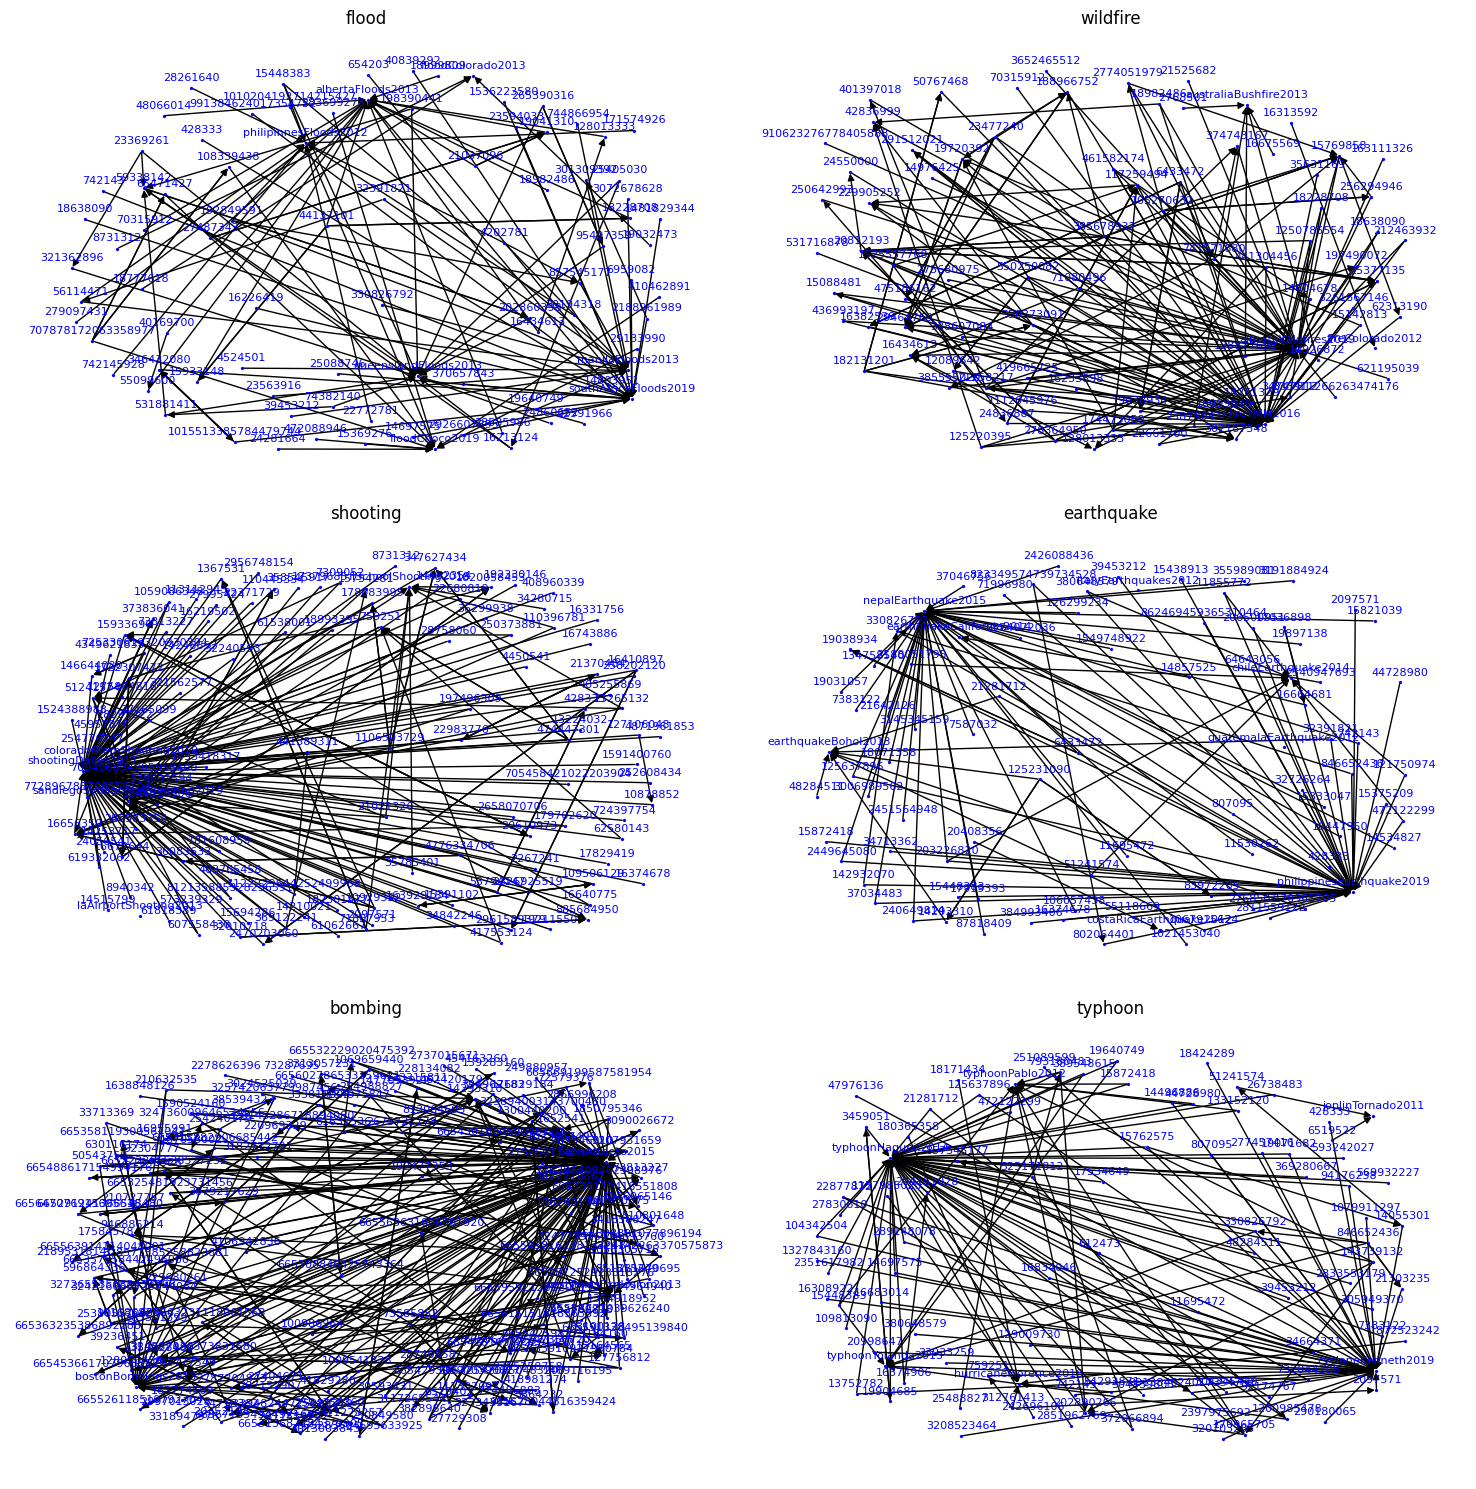

In [10]:
G = nx.read_graphml(pathData, node_type=str, edge_key_type=str)

# Extraire tous les `eventType` uniques
event_types = {data['eventType'] for node, data in G.nodes(data=True) if 'eventType' in data}
# Convertir en liste si nécessaire
event_types = list(event_types)
weightPos = {'bombing':2, 'shooting':6, 'earthquake':7, 'typhoon':10, 'flood':8, 'wildfire':15}
graph_list = []
 
for event_type in event_types: 
    weight = weightPos.get(event_type, 1)   
    subgraph = build_displayEventypeFamily(event_type)
    graph_list.append((weight, subgraph, event_type))
# Afficher les sous-graphes avec des titres correspondant aux eventTypes

display_multiple_subgraphs(graph_list)

__Ce schéma illustre clairement comment les différents éléments d'un graphe Twitter interagissent. Il peut être utilisé pour explorer diverses dimensions, comme l'engagement social, la diffusion de contenu, et l'analyse thématique. Si vous avez besoin d'une exploration plus détaillée ou d'autres visualisations, cela peut être approfondi avec des outils comme Neo4j__

In [11]:
# Chemin du répertoire contenant les fichiers JSON
path = "/Users/asriel/Library/Application Support/Neo4j Desktop/Application/relate-data/dbmss/dbms-2b32bab4-6f69-41b9-b387-635d89a4b98c/import/"
os.chdir(path)

# Répertoires contenant les fichiers JSON
nodes_directory = "Nodes"
relationships_directory = "Relationships"

In [12]:
def delete_all_nodes(driver):
    """Supprime tous les nœuds et leurs relations dans la base de données."""
    with driver.session() as session:
        query = "MATCH (n) DETACH DELETE n"
        session.run(query)
        print("Tous les nœuds et leurs relations ont été supprimés.")        

In [13]:
def load_json_file(file_path):
    """Charge un fichier JSON et retourne les données sous forme de liste."""
    # print(f'load_json_file : {file_path}')
    with open(file_path, 'r', encoding='utf-8') as file:
        data = []
        for line in file:
            try:
                data.append(json.loads(line.strip()))
            except json.JSONDecodeError as e:
                print(f"Erreur lors de la lecture de la ligne : {e}")
        return data

In [14]:
def create_node(driver, data):
    """Crée des nœuds dans la base de données Neo4j à partir des données fournies."""
    created_nodes = []
    with driver.session() as session:
        for entry in data:
            # Extract properties
            node_data = entry['n']
            properties = node_data['properties']
            external_id = node_data['id']  # Cet id est celui de niveau supérieur dans le JSON
            properties['external_id'] = external_id  # On l'ajoute aux propriétés pour le stocker dans Neo4j
            properties = entry['n']['properties']
            labels = ":".join(entry['n']['labels'])
            # Construct Cypher query
            cypher_query = f"CREATE (n:{labels} " + "{" + ", ".join([f"{key}: {json.dumps(value)}" 
                             for key, value in properties.items()]) + "})"
            try:
                # Exécuter la requête avec les propriétés dynamiques
                result = session.run(cypher_query)

                # Ajouter les nœuds créés à la liste
                for record in result:
                    created_nodes.append(record['n'])
            except Exception as e:
                # Gérer les erreurs potentielles
                print(f"Erreur lors de la création du nœud : {e}")
    return created_nodes            

In [15]:
def add_uuid_to_all_nodes(driver):
    """Ajoute un UUID à tous les nœuds qui n'ont pas encore de propriété uniqueId."""
    with driver.session() as session:
        session.run("""MATCH (n) WHERE n.uniqueId IS NULL SET n.uniqueId = randomUUID()""")

In [16]:
def create_nodes(driver):
    """Crée des nœuds et des relations à partir des fichiers JSON dans les répertoires spécifiés."""
    # Supprimer tous les nœuds existants
    #delete_all_nodes(driver)

    # Liste des fichiers JSON dans les répertoires
    node_files = [f for f in os.listdir(nodes_directory) if f.endswith(".json")]

    # Traiter les fichiers JSON dans le répertoire "Nodes"
    for file_name in node_files:
        file_path = os.path.join(nodes_directory, file_name)
        data = load_json_file(file_path)
        # Assurer que tous les éléments possèdent les attributs requis
        #complete_data = ensure_attributes(data, required_attributes, default_values)
        # Créer les nœuds
        created_nodes = create_node(driver, data)
        print(f"Fichier : {file_name} -> Nœuds créés avec toutes les propriétés.")
        
    # Ajouter des UUID à tous les nœuds
    add_uuid_to_all_nodes(driver)

In [17]:
def delete_all_relationShip(driver):
    """Supprime toutes les relations de la base de données."""
    with driver.session() as session:
        query = "MATCH ()-[r]->() DELETE r"
        session.run(query)
        print("Tous les relations ont été supprimées.")

In [18]:
def create_relationship(driver, data):
    """Crée des relations dans la base de données Neo4j à partir des données fournies."""
    with driver.session() as session:
        for entry in data:
            if 'r' in entry and entry['r'].get('type') == 'relationship':
                label = entry['r'].get('label')
                start_id = entry['r']['start'].get('id')
                start_label = entry['r']['start'].get('labels')
                end_id = entry['r']['end'].get('id')
                end_label = entry['r']['end'].get('labels')

                if start_id is None or end_id is None or label is None:
                    print(f"Erreur : Clé manquante dans l'entrée {entry}")
                    continue

                # Assurez-vous que les labels sont des chaînes de caractères
                if isinstance(start_label, list):
                    start_label = start_label[0]
                if isinstance(end_label, list):
                    end_label = end_label[0]

                # Construire dynamiquement la requête Cypher pour les relations
                query = f"""
                    MATCH (start:{start_label} {{external_id: $start_id}}), (end:{end_label} {{external_id: $end_id}})
                    CREATE (start)-[r:{label}]->(end)
                    RETURN r
                    """
                try:
                    # Exécuter la requête avec les identifiants dynamiques
                    session.run(query, start_id=start_id, end_id=end_id)
                except Exception as e:
                    print(f"Erreur lors de l'exécution de la requête : {e}")

In [19]:
def add_uuid_to_all_relationships(driver):
    """Ajoute un UUID à toutes les relations qui n'ont pas encore de propriété uniqueId."""
    with driver.session() as session:
        session.run("""
        MATCH ()-[r]->()
        WHERE r.uniqueId IS NULL
        SET r.uniqueId = randomUUID()
        """)

In [20]:
# Traiter les fichiers JSON dans le répertoire "Relationships"
def create_relationships(driver):
    
    #delete_all_relationShip(driver)
    relationship_files = [f for f in os.listdir(relationships_directory) if f.endswith(".json")]

    # Traiter les fichiers JSON dans le répertoire "Relationships"
    for file_name in relationship_files:
        file_path = os.path.join(relationships_directory, file_name)
        data = load_json_file(file_path)
        create_relationship(driver, data)
        print(f"Fichier : {file_name} -> Relations créées avec toutes les propriétés.")

    # Ajouter des UUID à tous les nœuds
    add_uuid_to_all_relationships(driver)

In [21]:
# Exécuter le processus de création de nœuds et de relations

def create_retweeted(driver):
    file_name = 'RETWEETED.json'
    file_path = path+"/"+relationships_directory+"/"+file_name
    # Traiter les fichiers JSON dans le répertoire "Relationships"
    data = load_json_file(file_path)
    create_relationship(driver, data)
    print(f"Fichier : {file_name} -> Relations créées avec toutes les propriétés.")

    # Ajouter des UUID à tous les nœuds
    add_uuid_to_all_relationships(driver)

In [22]:
from neo4j import GraphDatabase
# Connexion à la base Neo4j
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
#create_retweeted(driver)
# Exécuter le processus de création de nœuds et de relations
#create_nodes(driver)
#create_relationships(driver)
# Fermer la connexion
driver.close()

### __`Ce graphe est conçu sur la base de :`__

- __`noeuds multiples de différents types`__
- __`des relations de différents types user/item, item/item, user/user etc..`__

### __`Ce graphe est hétérogène`__

<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=600 large=400/>
</p>